In [1]:
# time series RNN model to predict sequence in data 
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from tensorflow.python.keras.models import Sequential
from tensorflow.python.keras.layers import SimpleRNN, Dense


In [2]:
def get_training_data_from_CSV(
        csv_file_with_path,
        training_percentage=0.7,
        scaling=True
):
    # Read only sunspots column
    df = pd.read_csv(csv_file_with_path, usecols=["Sunspots"])
    all_data = np.array(df.values, dtype="float32")

    if scaling:
        scaler = MinMaxScaler(feature_range=(0, 1))
        all_data = scaler.fit_transform(all_data).flatten()
    else:
        all_data = all_data.flatten()

    n = len(all_data)
    split_ptr = int(n * training_percentage)

    train_data = all_data[:split_ptr]
    test_data = all_data[split_ptr:]

    return train_data, test_data, all_data

def Prepare_Samples_as_input_seq_and_one_output(
        data_samples,
        Seq_Length=12
):
    # Indices of Y
    Y_index = np.arange(Seq_Length, len(data_samples), Seq_Length)
    Y = data_samples[Y_index]

    rows_x = len(Y)

    # Truncate to full sequences only
    X = data_samples[:Seq_Length * rows_x]
    X = np.reshape(X, (rows_x, Seq_Length, 1))

    # Print first 10 samples
    # for i in range(min(10, rows_x)):
    #     print(f"Step #{i}")
    #     print("X =", X[i].flatten())
    #     print("Y =", Y[i])
    #     print()

    return X, Y


In [3]:
def stacked_RNN(
        hidden_units,
        dense_units,
        sequence_length,
        input_vector_length,
        activation="tanh"
):
    input_shape = (sequence_length, input_vector_length)

    model = Sequential()

    model.add(SimpleRNN(
        hidden_units,
        return_sequences=True,
        input_shape=input_shape,
        name="First_Hidden"
    ))

    model.add(SimpleRNN(
        hidden_units,
        return_sequences=True,
        name="Second_Hidden"
    ))

    model.add(SimpleRNN(
        hidden_units,
        return_sequences=True,
        name="Third_Hidden"
    ))

    model.add(SimpleRNN(
        hidden_units,
        return_sequences=False,
        name="Fourth_Hidden"
    ))

    model.add(Dense(dense_units, activation=activation))

    model.compile(
        loss="mean_squared_error",
        optimizer="adam"
    )

    print(f"Input Shape: {input_shape}")
    model.summary()

    return model

In [4]:
csv_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-sunspots.csv"

train_data, test_data, all_data = get_training_data_from_CSV(
    csv_url,
    training_percentage=0.7,
    scaling=True
)

SEQ_LENGTH = 7

X_train, Y_train = Prepare_Samples_as_input_seq_and_one_output(
    train_data, Seq_Length=SEQ_LENGTH
)

X_test, Y_test = Prepare_Samples_as_input_seq_and_one_output(
    test_data, Seq_Length=SEQ_LENGTH
)


In [5]:
model = stacked_RNN(
    hidden_units=50,
    dense_units=1,
    sequence_length=SEQ_LENGTH,
    input_vector_length=1
)

history = model.fit(
    X_train,
    Y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, Y_test),
    verbose=1
)

Input Shape: (7, 1)
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
First_Hidden (SimpleRNN)     (None, 7, 50)             2600      
_________________________________________________________________
Second_Hidden (SimpleRNN)    (None, 7, 50)             5050      
_________________________________________________________________
Third_Hidden (SimpleRNN)     (None, 7, 50)             5050      
_________________________________________________________________
Fourth_Hidden (SimpleRNN)    (None, 50)                5050      
_________________________________________________________________
dense (Dense)                (None, 1)                 51        
Total params: 17,801
Trainable params: 17,801
Non-trainable params: 0
_________________________________________________________________
Epoch 1/50
18/18 [==============================] - 45s 96ms/step - loss: 0.1224 - val_loss: 0.020

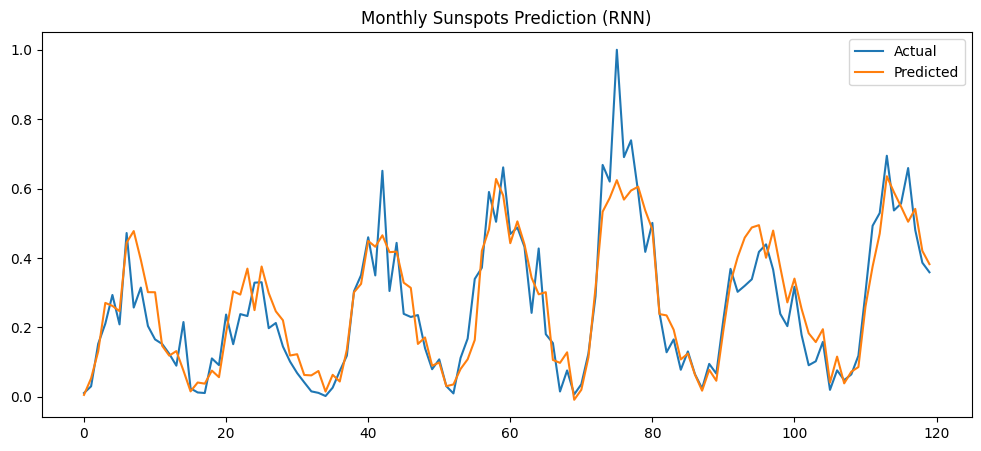

In [6]:
predictions = model.predict(X_test)

plt.figure(figsize=(12, 5))
plt.plot(Y_test, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.title("Monthly Sunspots Prediction (RNN)")
plt.show()


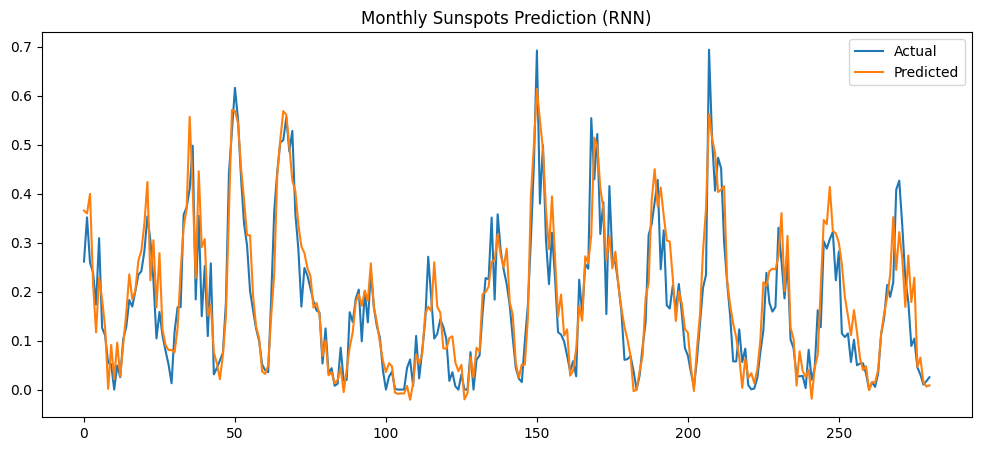

In [7]:
predictions = model.predict(X_train)

plt.figure(figsize=(12, 5))
plt.plot(Y_train, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.title("Monthly Sunspots Prediction (RNN)")
plt.show()